In [2]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
from sklearn.linear_model import LinearRegression  # For linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics
from sklearn.model_selection import train_test_split  # For splitting data into training and test sets
import lightgbm as lgb  # For LightGBM model
import xgboost as xgb  # For XGBoost model
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# Load the dataset
df = pd.read_csv("covid_19_india.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.groupby('Date')[['Confirmed']].sum().reset_index()

C:\Users\Sumi\AppData\Local\Temp\ipykernel_21160\3398016154.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [4]:
# Create lag feature (previous day's confirmed cases)
df['Lag_1'] = df['Confirmed'].shift(1)
df.dropna(inplace=True)

In [5]:
# Define features and target
X = df[['Lag_1']]
y = df['Confirmed']
dates = df['Date']


In [6]:
# Train-test split without shuffling (for time series)
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.2, shuffle=False
)


In [7]:
# === 1. Linear Regression ===
# Initialize and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
# Predict new cases using the Linear Regression model
y_pred_lr = lr_model.predict(X_test)


In [8]:
# === Evaluation ===
# Define a function to evaluate the model's performance using various metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)  # Mean Absolute Error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Root Mean Squared Error
    r2 = r2_score(y_true, y_pred)  # R-squared score
    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    }
# Evaluate all models and store the results
results = [
    evaluate_model(y_test, y_pred_lr, "Linear Regression"),
]

In [9]:
# Convert results into a DataFrame for better visualization
results_df = pd.DataFrame(results)
print("\n📊 Model Comparison:\n", results_df)



📊 Model Comparison:
                Model        MAE       RMSE  R2 Score
0  Linear Regression  124540.91  151056.35    0.9988


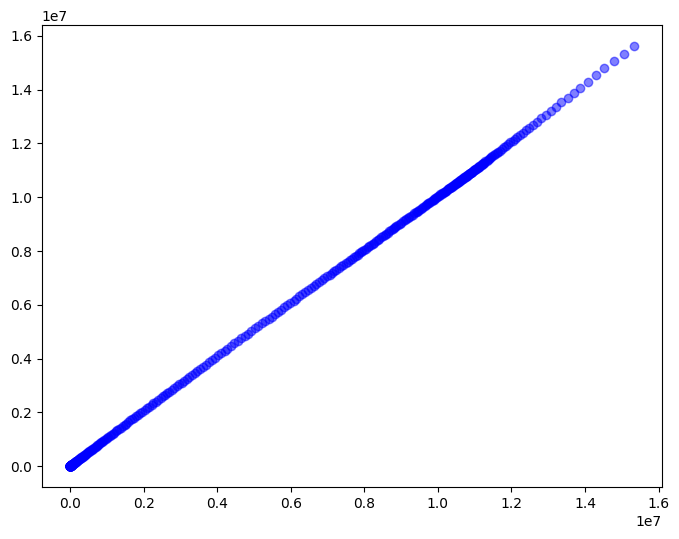

In [10]:
# === Step 2: Show the Linear Regression line being made (using one feature for visualization) ===
# We'll just use Lag_1 to illustrate the regression line visually
plt.figure(figsize=(8, 6))
plt.scatter(X_train['Lag_1'], y_train, alpha=0.5, label='Training Data', color='blue')

In [11]:
# === Step 3: Fit the actual model ===
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

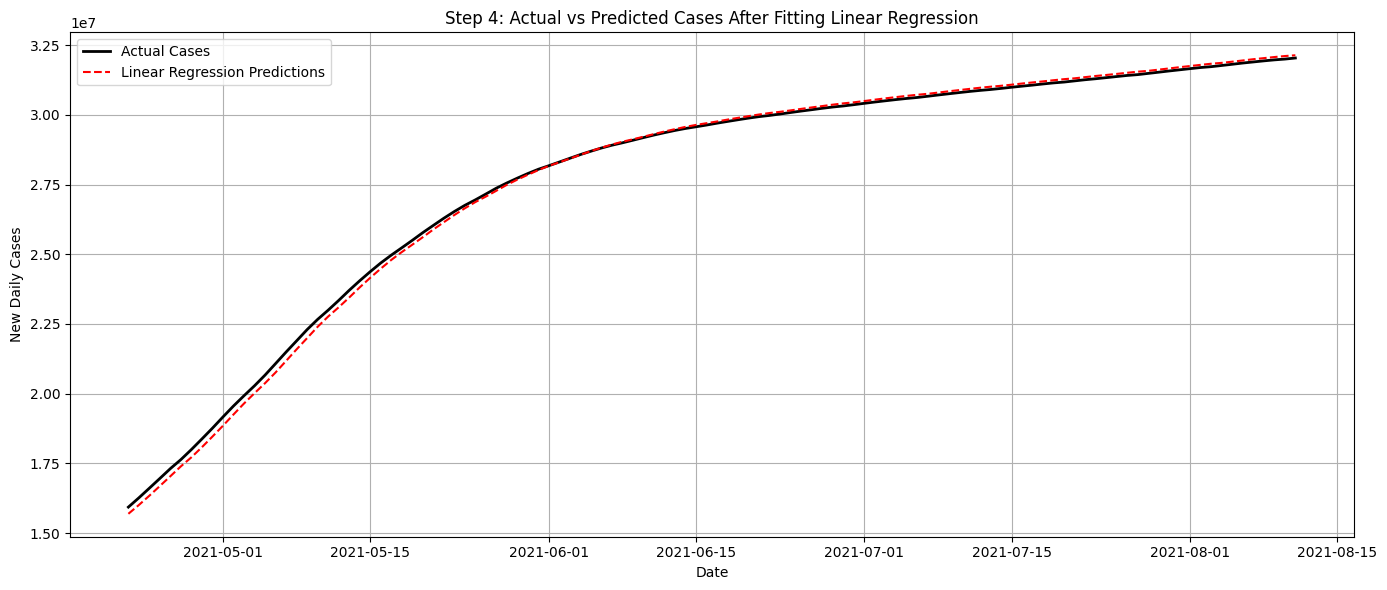

In [17]:
# === Step 4: Show how the model performs on the test set ===
# We'll plot actual vs predicted using the test set
y_pred_lr = lr_model.predict(X_test)

plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test.values, label="Actual Cases", color='black', linewidth=2)
plt.plot(dates_test, y_pred_lr, label="Linear Regression Predictions", linestyle='--', color='red')
plt.xlabel("Date")
plt.ylabel("New Daily Cases")
plt.title("Step 4: Actual vs Predicted Cases After Fitting Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
